## Extrema Time and Amplitude Taylor Series Expansion
This looks at the taylor series expansion of extrema of surface temperature as a deviation from the first harmonic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import itertools
import xarray as xr
import scipy.optimize
from scipy.interpolate import CubicSpline

from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots, colored_line
from isca_tools.thesis.surface_energy_budget import get_param_dimensionless, get_temp_extrema_theory, \
    get_temp_shift_params
from isca_tools.utils.constants import R, c_p_water, rho_water
from isca_tools.thesis.mod_parcel_theory import get_temp_mod_parcel, get_scale_factor_theory_numerical2, \
    get_scale_factor_theory
from isca_tools.thesis.surface_flux_taylor import get_latent_heat, get_sensitivity_lh, reconstruct_lh, name_nl, \
    name_square, reconstruct_sh, reconstruct_lw, get_sensible_heat, get_lwup_sfc_net, get_temp_rad, get_sensitivity_sh, \
    get_sensitivity_lw
import inspect
import copy
import jobs.thesis_season.thesis_figs.utils as utils
from isca_tools.utils.radiation import get_heat_capacity
from isca_tools.utils.xarray import update_dim_slice

warnings.filterwarnings('ignore')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
width = {'one_col': 3.2, 'two_col': 5.5}  # width in inches
im_sz = 1.5
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [3]:
# Load actual data for check flux calculations match simulated and to do example decomposition
ds_base = utils.load_ds(depth=20, reduced_evap=False).isel(
    lat=-1).squeeze()  # only use one latitude, highest so the biggest seasonal cycle as a test
# ds_base = utils.load_ds(depth=5, reduced_evap=False).sel(lat=42,
#                                                          method='nearest').squeeze()  # only use one latitude, highest so the biggest seasonal cycle as a test
ds_test = ds_base.isel(lon=np.random.randint(0, ds_base.lon.size - 1), time=slice(0,
                                                                                  360))  # choose the first year at a single longitude (different each time) as sanity check formulae work
ds = utils.get_annual_zonal_mean(ds_base)  # smoothed average version
ds['flux_net'] = ds.flux_lhe + ds.flux_t + ds.lwup_sfc - ds.lwdn_sfc  # compute net flux with smoothed variables

  0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
temp_surf_anom = {'simulated': ds.temp_surf - ds.temp_surf.mean()}
surf_flux_up_params = utils.polyfit_phase_xr(temp_surf_anom['simulated'],
                                             ds.flux_net,
                                             deg=2,
                                             include_phase=True, include_fourier=True)
temp_surf_anom['approx'], _, _, var, _ = utils.get_temp_fourier_analytic_xr(ds.time, ds.swdn_sfc, ds.heat_capacity,
                                                                            surf_flux_up_params,
                                                                            n_harmonics=2)
# Compute shortwave radiation with just a single harmonic
sw_amp1 = float(var.sel(harmonic=1))
sw_amp2 = float(var.sel(harmonic=2))
sw_single_harmonic = utils.fourier_series_xr(ds.time, var * [1, 1, 0], var * 0, pad_coefs_phase=True)

In [5]:
def get_t1(flux_params=surf_flux_up_params,
           heat_capacity=ds.heat_capacity, extrema_ind=1, n_days_year=ds.time.size):
    # Returns time in days
    f = 1 / (n_days_year * utils.day_seconds)
    heat_capacity_eff = heat_capacity * (1 - flux_params.sel(deg='phase') / (2 * np.pi * f * heat_capacity))
    x = float(2 * np.pi * f * heat_capacity_eff / flux_params.sel(deg='1'))
    time_harmonic1 = np.arctan(x) / (2 * np.pi * f)
    if extrema_ind == 2:
        time_harmonic1 = time_harmonic1 + 1 / (2 * f)
    return time_harmonic1 / utils.day_seconds


def get_y(time=ds.time, heat_capacity=ds.heat_capacity, flux_params=surf_flux_up_params,
          extrema_ind=1, n_days_year=ds.time.size):
    # Returns y=sin(2\pi f\Delta) where \Delta=t_extrema - t_extrema_1
    # I.e. the time relative to first harmonic
    f = 1 / (n_days_year * utils.day_seconds)
    time_harmonic1 = get_t1(flux_params=flux_params, heat_capacity=heat_capacity, extrema_ind=extrema_ind,
                            n_days_year=n_days_year) * utils.day_seconds
    time_shift = time * utils.day_seconds - time_harmonic1  # shift in seconds
    y = np.sin(2 * np.pi * f * time_shift)
    # temp_spline = CubicSpline(np.append(time, time[-1]+1), np.append(temp, temp[0]), bc_type='periodic')
    return y

In [6]:
def sort_arrays_by_first(arr1, arr2):
    # Combine arr1 and arr2 into tuples
    combined = list(zip(arr1, arr2))

    # Sort the combined list based on arr1 (the first element of each tuple)
    sorted_combined = sorted(combined, key=lambda x: x[0])

    # Extract sorted arrays from sorted_combined
    sorted_arr1 = [item[0] for item in sorted_combined]
    sorted_arr2 = [item[1] for item in sorted_combined]

    return sorted_arr1, sorted_arr2

In [7]:
def get_extrema_theory(time=ds.time, swdn_sfc=ds.swdn_sfc, flux_params=surf_flux_up_params,
                       heat_capacity=ds.heat_capacity, harmonic_extrema_ind=1, n_days_year=ds.time.size,
                       approx: bool = False, approx_a_params='linear', get_a_from_func: bool = False):
    # If approx=True then uses algebra for y_ex as linear sum of mechanisms
    # If approx_a_params=True, approximates a2 and a3 as linear sum of mechanisms
    # but then solves numerically fo y_ex
    # harmonic_extrema_ind==1 is winter and 2 is summer
    f = 1 / (n_days_year * utils.day_seconds)
    x0 = float(2 * np.pi * f * heat_capacity / flux_params.sel(deg='1'))
    var = utils.get_temp_fourier_analytic_xr(time, swdn_sfc, heat_capacity, surf_flux_up_params)
    x1 = float(np.tan(var[2].sel(harmonic=1)))
    x2 = float(np.tan(var[2].sel(harmonic=2)))
    sw_amp1 = float(var[3].sel(harmonic=1))
    sw_amp_ratio = float(var[3].sel(harmonic=2) / sw_amp1)
    lambda_const = float(flux_params.sel(deg='1'))
    lambda_cos = float(get_param_dimensionless(flux_params.sel(deg='cos'), sw_fourier_amp1=sw_amp1))
    lambda_sin = float(get_param_dimensionless(flux_params.sel(deg='sin'), sw_fourier_amp1=sw_amp1))
    lambda_sq = float(
        get_param_dimensionless(flux_params.sel(deg='2'), sw_fourier_amp1=sw_amp1, lambda_const=lambda_const))
    lambda_ph = float(
        get_param_dimensionless(flux_params.sel(deg='phase'), heat_capacity=heat_capacity, n_year_days=n_days_year))
    a_1 = sw_amp1 / lambda_const / np.sqrt(1 + x1 ** 2) * [1, -1][harmonic_extrema_ind - 1]

    # Approx
    sw_amp_ratio_mod = sw_amp_ratio - lambda_cos
    if get_a_from_func:
        a_1, a_2, a_3 = get_temp_shift_params(heat_capacity, sw_amp1, sw_amp2, flux_params.sel(deg='1'),
                                              flux_params.sel(deg='phase'),
                                              flux_params.sel(deg='2'), flux_params.sel(deg='cos'),
                                              flux_params.sel(deg='sin'),
                                              n_year_days=n_days_year, approx_level=approx_a_params)
        a_1 = float(a_1) * [1, -1][harmonic_extrema_ind - 1]
        a_2 = float(a_2)
        a_3 = float(a_3)
    else:
        if approx_a_params == 'linear':
            a_2 = sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 4 * x0 ** 2) * (
                    sw_amp_ratio_mod * (4 * x1 * x0 - x1 ** 2 + 1) - lambda_sin * 2 * (
                    x0 * x1 ** 2 + x1 - x0) - lambda_sq)
            a_3 = -2 * sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 4 * x0 ** 2) * (
                    sw_amp_ratio_mod * 2 * (x1 - x0 + x0 * x1 ** 2) + lambda_sin * (
                    4 * x0 * x1 - x1 ** 2 + 1) + lambda_sq * 2 * x0)
        elif approx_a_params == 'linear_phase':
            prefactor = sw_amp1 / lambda_const / (1 + x0 ** 2) / (1 + 4 * x0 ** 2)
            lambda_ph_mod = lambda_ph / (1 + x0 ** 2)
            a_1 = 1 / (lambda_const / sw_amp1 * np.sqrt(1 + x0 ** 2) * (1 - x0 ** 2 * lambda_ph_mod))
            a_1 = a_1 * [1, -1][harmonic_extrema_ind - 1]
            a_2 = prefactor * ((3 * x0 ** 2 + 1 + 4 * x0 ** 4 * lambda_ph_mod) * sw_amp_ratio_mod -
                               2 * x0 * (x0 ** 2 - (3 * x0 ** 2 + 1) * lambda_ph_mod) * lambda_sin -
                               (1 + 2 * x0 ** 2 * lambda_ph_mod) * lambda_sq)
            a_3 = -2 * prefactor * ((2 * x0 ** 3 - 2 * x0 * (3 * x0 ** 2 + 1) * lambda_ph_mod) * sw_amp_ratio_mod +
                                    (3 * x0 ** 2 + 1 + 4 * x0 ** 4 * lambda_ph_mod) * lambda_sin +
                                    2 * x0 * (1 + 2 * x0 ** 2 * lambda_ph_mod) * lambda_sq)
        elif approx_a_params is None:
            # Actual exact values
            alpha_1 = lambda_sq / (sw_amp_ratio - lambda_cos) * (1 - x1 ** 2) / (1 + x1 ** 2) ** 2
            prefactor = sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 2 * x0 * x2) * (sw_amp_ratio - lambda_cos) * (
                    1 - alpha_1)
            prefactor_x2 = prefactor * x2
            a_2 = prefactor * (1 - x1 ** 2) + 2 * x1 * prefactor_x2
            a_3 = -4 * prefactor * x1 - 2 * prefactor_x2 * (x1 ** 2 - 1)

    if approx:
        ph_factor = 1 - lambda_ph
        y_extrema = 2 / np.sqrt(1 + x0 ** 2 * ph_factor ** 2) / (1 + 4 * x0 ** 2) * (
                sw_amp_ratio_mod * 2 * x0 * (x0 ** 2 * ph_factor ** 2 - lambda_ph) + lambda_sq * 2 * x0 +
                lambda_sin * ((3 - lambda_ph) * (lambda_ph + 1) * x0 ** 2 + 1)
        )
        if harmonic_extrema_ind != 2:
            y_extrema *= -1
        y_extrema += 16 * x0 / (1 + x0 ** 2 * ph_factor ** 2) / (1 + 4 * x0 ** 2) ** 2 * (
                (3 + lambda_ph) * (1 - lambda_ph) * x0 ** 2 + 1) * (
                             ph_factor * x0 ** 2 - lambda_ph) * sw_amp_ratio_mod ** 2
        y_extrema -= 16 * x0 / (1 + x0 ** 2 * ph_factor ** 2) / (
                1 + 4 * x0 ** 2) ** 2 * lambda_sq ** 2  # squared lambda_sq term
        y_extrema -= 16 / (1 + x0 ** 2 * ph_factor ** 2) / (
                1 + 4 * x0 ** 2) ** 2 * (x0 * x1 ** 2 + x1 - x0) * (
                             4 * x0 * x1 - x1 ** 2 + 1) * lambda_sin ** 2  # squared lambda_sin term
        # y_extrema += 16*x0/(1 + x0 ** 2 * ph_factor ** 2) / (1 + 4 * x0 ** 2)**2 * (2 * x1 * (2*x0-x1)-1) * lambda_sq*sw_amp_ratio_mod
    T_func = lambda y: a_1 * np.sqrt(1 - y ** 2) + a_2 * (1 - 2 * y ** 2) + a_3 * y * np.sqrt(1 - y ** 2)
    dT_dt_func = lambda y: (-a_1 * y - 4 * a_2 * y * np.sqrt(1 - y ** 2) + a_3 * (
            1 - 2 * y ** 2)) * 2 * np.pi * f * utils.day_seconds  # K/days

    if not approx:
        y_extrema = scipy.optimize.least_squares(dT_dt_func, 0, bounds=(-1, 1))['x'][0]
    return y_extrema, T_func, dT_dt_func

In [108]:
# Sanity check that get same results from above func and that in isca_tools of extrema from different methods
method_numerical = 'linear_phase'
for key in ['approx', 'numerical']:
    for i in range(1, 3):
        var = get_temp_extrema_theory(float(ds.heat_capacity), sw_amp1, sw_amp2,
                                      float(surf_flux_up_params.sel(deg='1')),
                                      float(surf_flux_up_params.sel(deg='phase')),
                                      float(surf_flux_up_params.sel(deg='2')),
                                      float(surf_flux_up_params.sel(deg='cos')),
                                      float(surf_flux_up_params.sel(deg='sin')), extrema_ind=i,
                                      numerical=key == 'numerical', approx_level=method_numerical)
        if key == 'approx':
            var = float(var[1])
        else:
            var = float(var[1] + var[2]['nl_residual'])
        var2 = get_extrema_theory(approx=key == 'approx', harmonic_extrema_ind=i, get_a_from_func=False,
                                  approx_a_params=method_numerical)[0]
        print(f"{key} | Extrema {i} | y = {var:.3f} | Error = {var - var2:.2g}")
        if np.abs(var - var2) > 1e-2:
            raise ValueError('Inconsistent Calculations')
print('Success!')

approx | Extrema 1 | y = 0.440 | Error = -0.0074
approx | Extrema 2 | y = -0.313 | Error = -0.0065
numerical | Extrema 1 | y = 0.335 | Error = -5.6e-17
numerical | Extrema 2 | y = -0.281 | Error = 1.4e-15
Success!


### Derivative and temperature as function of $y$
Below I shift the time coordinate of temperature and plot T as a function of time difference from extrema of first harmonic. I also plot the derivative, where this crosses zero is the extrema time.

The blue dashed and black solid lines should overlap exactly if `use_algebra=False` below as there is no approximation, just a shift in time coordinate. This seems to be the case here. If `use_algebra=True`, there is approximation but it seems to perform remarkably well.

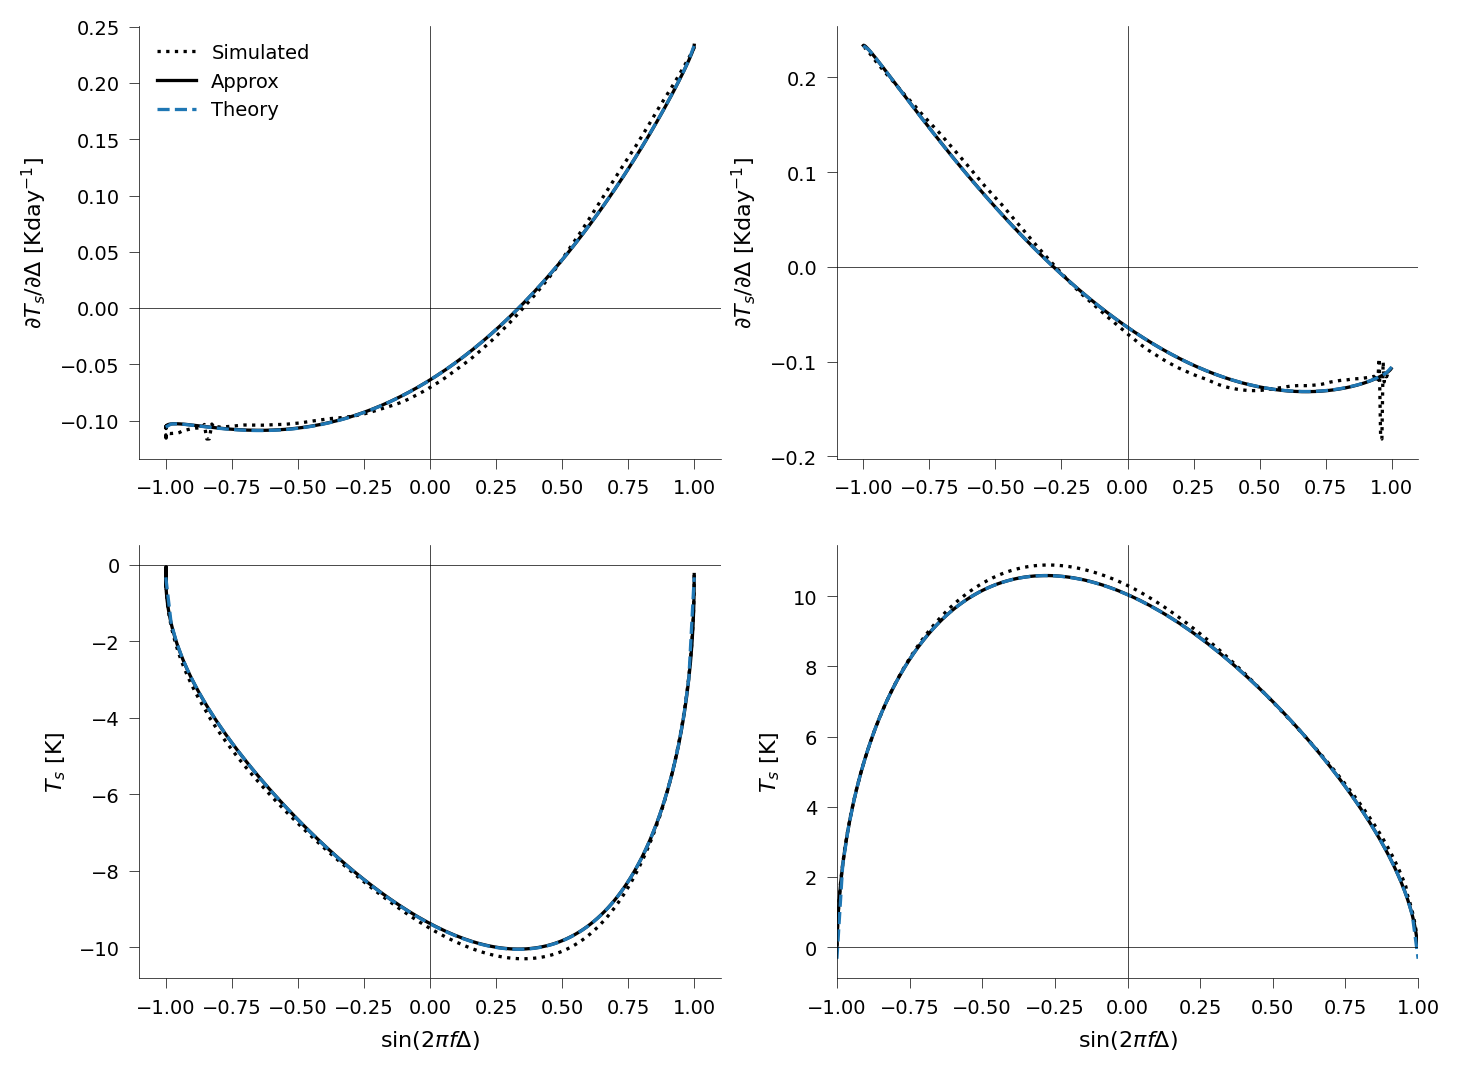

In [9]:
y_plot = np.linspace(-1, 1, 100)
linestyle_use = {'simulated': ':', 'approx': '-'}
fig, ax = plt.subplots(2, 2)
fig_resize(fig, width['two_col'] * 1.5)
method_numerical = 'linear_phase'  # quite severe approx but still basically perfect

for i in range(1, 3):
    # Plot simulated and direct fourier stuff
    ax[0, i - 1].set_ylabel('$\partial T_s/\partial \Delta$ [Kday$^{-1}$]')
    ax[1, i - 1].set_ylabel('$T_s$ [K]')
    spline_y = get_y(extrema_ind=i).values
    func_use = get_extrema_theory(harmonic_extrema_ind=i, get_a_from_func=False,
                                  approx_a_params=method_numerical)[1:]  # phase of 1st harmonic extrema
    if i == 2:
        use_ind = temp_surf_anom['simulated'] > 0
        # x1 = -1 * x1
    else:
        use_ind = temp_surf_anom['simulated'] < 0
    for key2 in temp_surf_anom:
        # use smoothed temp as use smoothed temp to find simulated extrema in time_extrema_temp
        spline_temp = CubicSpline(np.append(ds.time, ds.time[-1] + 1), np.append(temp_surf_anom[key2],
                                                                                 temp_surf_anom[key2][0]),
                                  bc_type='periodic')
        var2 = sort_arrays_by_first(spline_y[use_ind], spline_temp.derivative()(ds.time)[use_ind])
        ax[0, i - 1].plot(var2[0], var2[1], color='k', label=key2.capitalize(), linestyle=linestyle_use[key2])

        var2 = sort_arrays_by_first(spline_y[use_ind], spline_temp(ds.time)[use_ind])
        ax[1, i - 1].plot(var2[0], var2[1], color='k', label=key2, linestyle=linestyle_use[key2])
    ax[0, i - 1].plot(y_plot, func_use[1](y_plot), color='C0', label='Theory', linestyle='--')
    # For temperature, ensure the starting temperature of the integral is same as spline
    ax[1, i - 1].plot(y_plot, func_use[0](y_plot) - 0 * (func_use[0](float(var2[0][0])) + var2[1][0]), color='C0',
                      label='Theory', linestyle='--')

update_linewidth(fig)
for ax_use in ax.flatten():
    ax_use.axhline(0, color='k', lw=ax_linewidth)
    ax_use.axvline(0, color='k', lw=ax_linewidth)
ax[0, 0].legend()
ax[1, 0].set_xlabel('$\sin(2\pi f \Delta)$')
ax[1, 1].set_xlabel('$\sin(2\pi f \Delta)$')
ax[1, 1].set_xlim(-1, 1)
plt.show()

### Role of each parameter
Below I plot how each parameter affects the amplitude and time of the extrema. I also see if the approximations are correct at capturing this.

In [61]:
# Compare approx and numerical for a range of values
plot_const_val = {}
plot_const_val['heat_capacity'] = get_heat_capacity(c_p_water, rho_water, layer_depth=5)
plot_const_val['lambda_const'] = 3
# plot_const_val['lambda_phase'] = 1        # for sanity check that works with non zero phase param
plot_const_val['lambda_phase'] = 0
plot_const_val['sw_amp1'] = -140

# Dimensionless forms of parameters
n_range_val = 21
plot_range_val = {'sw': np.linspace(-0.43, 0.43, n_range_val),
                  'square': np.linspace(-0.7, 0.7, n_range_val),
                  'cos': np.linspace(-0.2, 0.2, n_range_val),
                  'sin': np.linspace(-0.2, 0.2, n_range_val),
                  'phase': np.linspace(-0.5, 0.5, n_range_val)}

extrema_time_range = {key2: {key: np.zeros((2, n_range_val)) for key in plot_range_val} for key2 in
                      ['numerical', 'linear', 'square']}
extrema_amp_range = {key2: {key: np.zeros((2, n_range_val)) for key in plot_range_val} for key2 in
                     ['numerical', 'linear', 'square']}

for k in range(2):
    for i in range(n_range_val):
        plot_const_val['sw_amp2'] = plot_const_val['sw_amp1'] * plot_range_val['sw'][i]
        plot_const_val['lambda_sq'] = get_param_dimensionless(plot_range_val['square'][i],
                                                              lambda_const=plot_const_val['lambda_const'],
                                                              sw_fourier_amp1=plot_const_val['sw_amp1'], invert=True)
        plot_const_val['lambda_cos'] = get_param_dimensionless(plot_range_val['cos'][i],
                                                               sw_fourier_amp1=plot_const_val['sw_amp1'], invert=True)
        plot_const_val['lambda_sin'] = get_param_dimensionless(plot_range_val['sin'][i],
                                                               sw_fourier_amp1=plot_const_val['sw_amp1'], invert=True)
        for key2 in ['numerical', 'linear']:
            var = get_temp_extrema_theory(**plot_const_val, numerical=key2 == 'numerical', extrema_ind=k + 1)
            for key3 in extrema_time_range[key2]:
                if key3 == 'phase':
                    continue
                extrema_time_range[key2][key3][k, i] = var[2][key3]
                if (key2 == 'linear') and (f'nl_{key3}' in var[2]):
                    extrema_time_range['square'][key3][k, i] = extrema_time_range['linear'][key3][k, i] + var[2][
                        f'nl_{key3}']

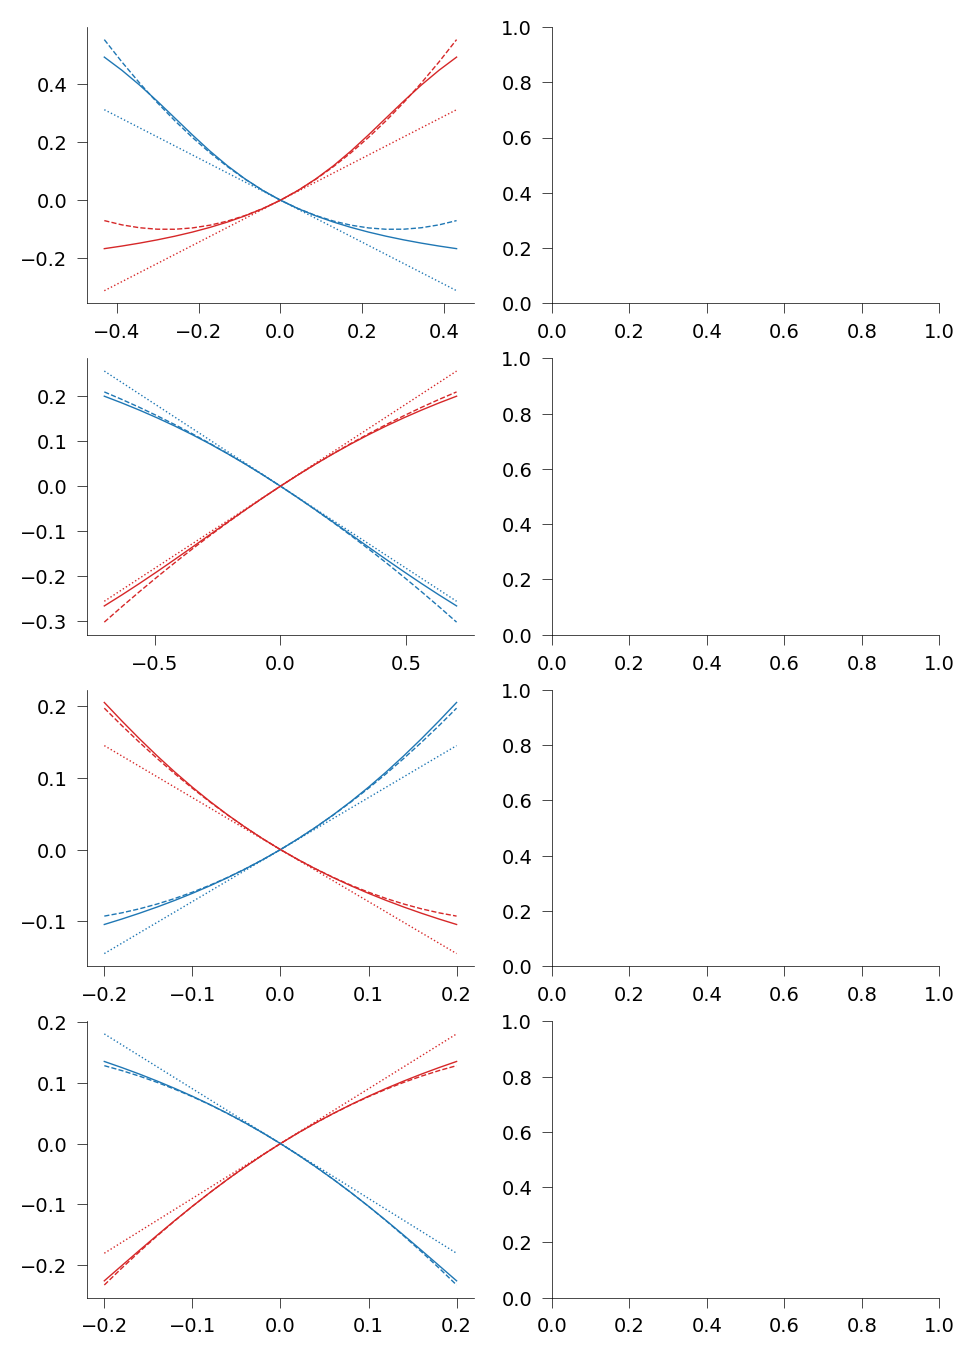

In [62]:
color_use = ['C0', 'C3']  # blue is minima and red is maxima
linestyle_use = {'numerical': '-', 'linear': ':', 'square': '--'}
fig, ax = plt.subplots(4, 2)
fig_resize(fig, width['two_col'])
for i, key in enumerate(plot_range_val):
    if key == 'phase':
        continue
    for key2 in extrema_time_range:
        for j in range(extrema_time_range[key2][key].shape[0]):
            ax[i, 0].plot(plot_range_val[key], extrema_time_range[key2][key][j], color=color_use[j],
                          linestyle=linestyle_use[key2])

### Influence of $\lambda_{ph}'$ on Extrema

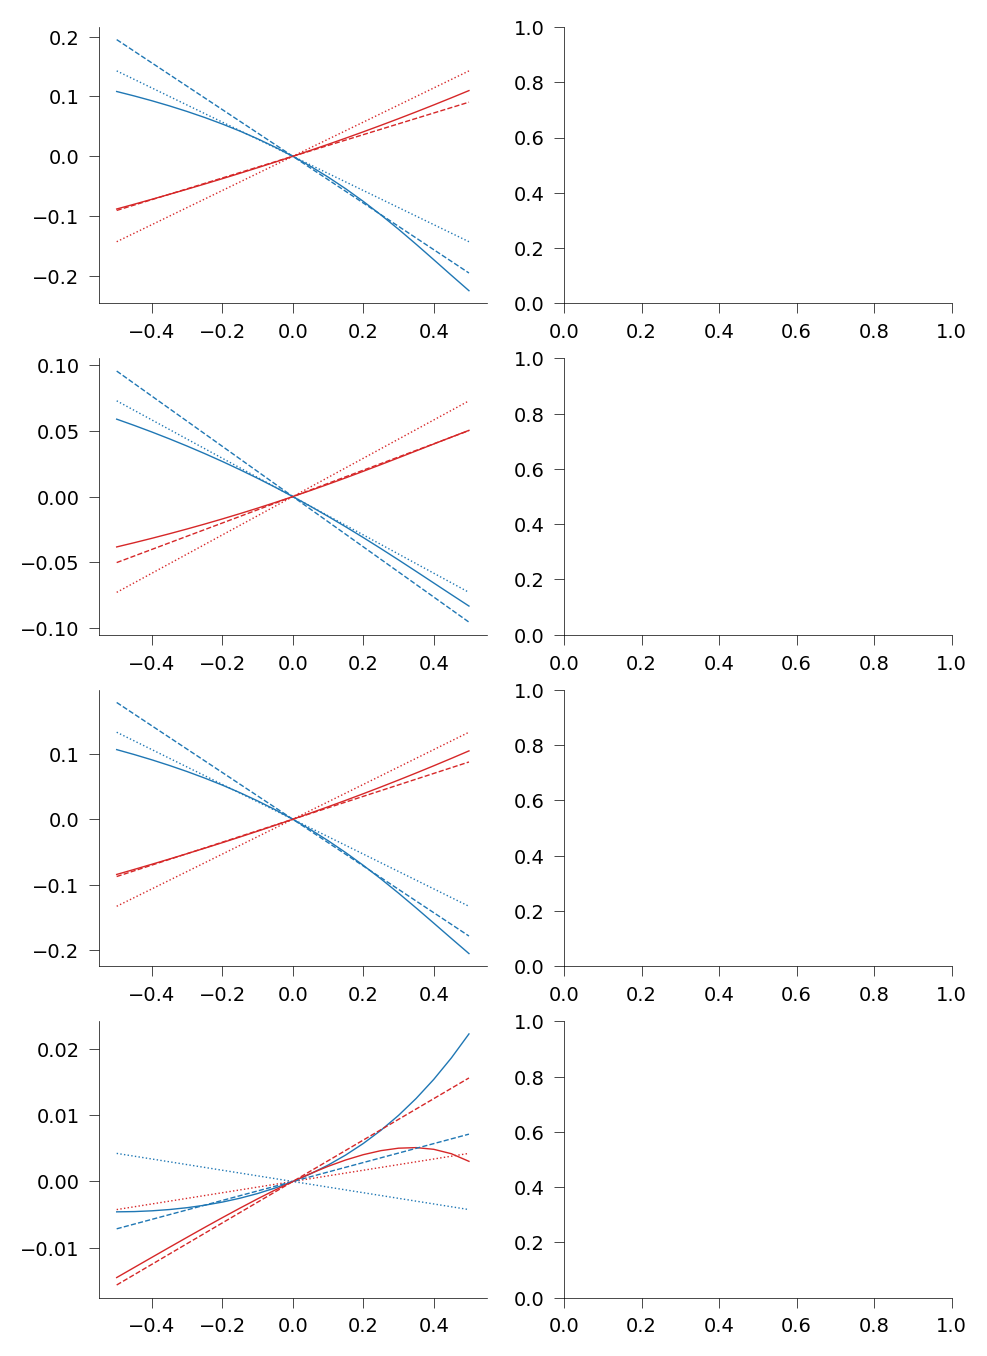

In [98]:
params_use_ph = copy.deepcopy(plot_const_val)
params_use_ph['sw_amp2'] = 30
params_use_ph['lambda_cos'] = get_param_dimensionless(0.2, sw_fourier_amp1=plot_const_val['sw_amp1'], invert=True)
params_use_ph['lambda_sin'] = get_param_dimensionless(0.1, sw_fourier_amp1=plot_const_val['sw_amp1'], invert=True)
params_use_ph['lambda_sq'] = get_param_dimensionless(0.6, lambda_const=plot_const_val['lambda_const'],
                                                     sw_fourier_amp1=plot_const_val['sw_amp1'], invert=True)

extrema_time_range_ph = {key2: {key: np.zeros((2, n_range_val)) for key in plot_range_val} for key2 in
                         ['numerical', 'linear', 'square']}
extrema_amp_range_ph = {key2: {key: np.zeros((2, n_range_val)) for key in plot_range_val} for key2 in
                        ['numerical', 'linear', 'square']}
params_use_no_ph = copy.deepcopy(params_use_ph)
params_use_no_ph['lambda_phase'] = 0
for k in range(2):
    for i in range(n_range_val):
        params_use_ph['lambda_phase'] = get_param_dimensionless(plot_range_val['phase'][i],
                                                                heat_capacity=params_use_ph['heat_capacity'],
                                                                n_year_days=ds.time.size, invert=True)
        for key2 in ['numerical', 'linear']:
            var = get_temp_extrema_theory(**params_use_ph, numerical=key2 == 'numerical', extrema_ind=k + 1)
            var_no_phase = get_temp_extrema_theory(**params_use_no_ph, numerical=key2 == 'numerical', extrema_ind=k + 1)
            for key3 in extrema_time_range_ph[key2]:
                if key3 == 'phase':
                    continue
                extrema_time_range_ph[key2][key3][k, i] = var[2][key3] - var_no_phase[2][key3]
                if (key2 == 'linear') and (f'nl_{key3}' in var[2]):
                    extrema_time_range_ph['square'][key3][k, i] = var[2][key3] + var[2][f'nl_{key3}'] - (var_no_phase[2][key3] + var_no_phase[2][f'nl_{key3}'])

fig, ax = plt.subplots(4, 2)
fig_resize(fig, width['two_col'])
for i, key in enumerate(plot_range_val):
    if key == 'phase':
        continue
    for key2 in extrema_time_range_ph:
        # if key2 == 'linear':
        #     continue
        for j in range(extrema_time_range_ph[key2][key].shape[0]):
            ax[i, 0].plot(plot_range_val['phase'], extrema_time_range_ph[key2][key][j], color=color_use[j],
                          linestyle=linestyle_use[key2])

### Sanity check of $a_2$ and $a_3$ dependence on $\lambda_{ph}'$

In [99]:
def get_a_factors(sw_amp1, sw_amp2, lambda_const, lambda_phase, lambda_sq, lambda_cos, lambda_sin, heat_capacity,
                  n_days_year=ds.time.size, approx: bool = False):
    f = 1 / (n_days_year * utils.day_seconds)
    x = 2 * np.pi * f * heat_capacity / lambda_const
    # Make params dimensionless
    lambda_cos = get_param_dimensionless(lambda_cos, sw_fourier_amp1=sw_amp1)
    lambda_sin = get_param_dimensionless(lambda_sin, sw_fourier_amp1=sw_amp1)
    lambda_sq = get_param_dimensionless(lambda_sq, sw_fourier_amp1=sw_amp1, lambda_const=lambda_const)
    lambda_ph = get_param_dimensionless(lambda_phase, heat_capacity=heat_capacity, n_year_days=n_days_year)
    x1 = x * (1 - lambda_ph)

    sw_amp_ratio = sw_amp2 / sw_amp1
    sw_amp_ratio_mod = sw_amp_ratio - lambda_cos
    if approx:
        prefactor = sw_amp1 / lambda_const / (1 + x ** 2) / (1 + 4 * x ** 2)
        lambda_ph_mod = lambda_ph / (1 + x ** 2)
        a_2 = prefactor * ((3 * x ** 2 + 1 + 4 * x ** 4 * lambda_ph_mod) * sw_amp_ratio_mod -
                           2 * x * (x ** 2 - (3 * x ** 2 + 1) * lambda_ph_mod) * lambda_sin -
                           (1 + 2 * x ** 2 * lambda_ph_mod) * lambda_sq)
        a_3 = -2 * prefactor * ((2 * x ** 3 - 2 * x * (3 * x ** 2 + 1) * lambda_ph_mod) * sw_amp_ratio_mod +
                                (3 * x ** 2 + 1 + 4 * x ** 4 * lambda_ph_mod) * lambda_sin +
                                2 * x * (1 + 2 * x ** 2 * lambda_ph_mod) * lambda_sq)
    else:
        a_2 = sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 4 * x ** 2) * (
                sw_amp_ratio_mod * (4 * x1 * x - x1 ** 2 + 1) - lambda_sin * 2 * (x * x1 ** 2 + x1 - x) - lambda_sq)
        a_3 = -2 * sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 4 * x ** 2) * (
                sw_amp_ratio_mod * 2 * (x1 - x + x * x1 ** 2) + lambda_sin * (
                4 * x * x1 - x1 ** 2 + 1) + lambda_sq * 2 * x)
    return a_2, a_3

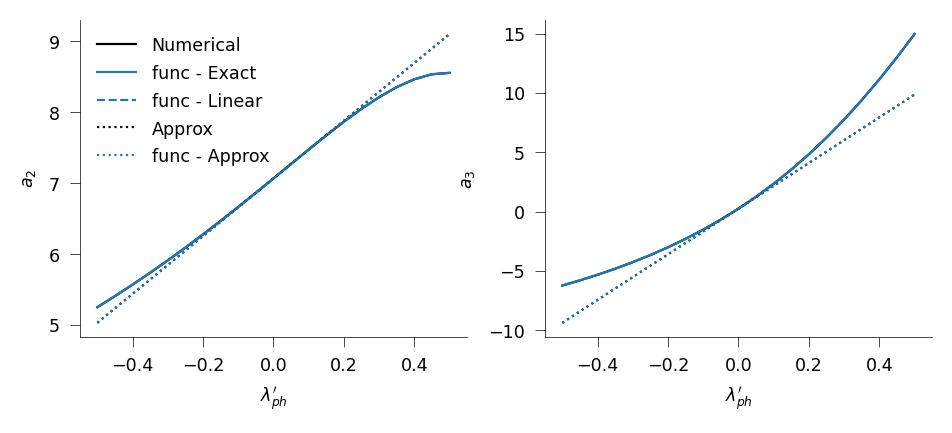

In [100]:
# params_use = copy.deepcopy(plot_const_val)
# plot_range_val['phase'] = np.linspace(-0.3, 0.3, n_range_val)
params_use_ph['lambda_phase'] = get_param_dimensionless(plot_range_val['phase'],
                                                     heat_capacity=params_use_ph['heat_capacity'],
                                                     n_year_days=ds.time.size, invert=True)
# params_use['sw_amp2'] = 50
# params_use['lambda_cos'] = get_param_dimensionless(0.2, sw_fourier_amp1=plot_const_val['sw_amp1'], invert=True)
# params_use['lambda_sin'] = get_param_dimensionless(0.2, sw_fourier_amp1=plot_const_val['sw_amp1'], invert=True)
# params_use['lambda_sq'] = get_param_dimensionless(0.7, lambda_const=plot_const_val['lambda_const'],
#                                                   sw_fourier_amp1=plot_const_val['sw_amp1'], invert=True)
var = get_a_factors(**params_use_ph, approx=True)
var_func = get_temp_shift_params(**params_use_ph, approx_level='linear_phase')
var_num = get_a_factors(**params_use_ph, approx=False)
var_num_func = get_temp_shift_params(**params_use_ph, approx_level=None)
var_num_func_linear = get_temp_shift_params(**params_use_ph, approx_level='linear')
fig, ax = plt.subplots(1, 2, sharex=True)
fig_resize(fig, width['two_col'])
for i in range(len(var)):
    ax[i].plot(plot_range_val['phase'], var_num[i], color='k', label='Numerical')
    ax[i].plot(plot_range_val['phase'], var_num_func[i + 1], color='C0', label='func - Exact')
    ax[i].plot(plot_range_val['phase'], var_num_func_linear[i + 1], color='C0', label='func - Linear', linestyle='--')
    ax[i].plot(plot_range_val['phase'], var[i], color='k', linestyle=':', label='Approx')
    ax[i].plot(plot_range_val['phase'], var_func[i + 1], color='C0', linestyle=':', label='func - Approx')
update_linewidth(fig)
ax[0].legend()
ax[0].set_ylabel('$a_2$')
ax[1].set_ylabel('$a_3$')
ax[0].set_xlabel("$\lambda_{ph}'$")
ax[1].set_xlabel("$\lambda_{ph}'$")
update_fontsize(fig)
plt.show()